# Week 3: Statistical Analysis and Hypothesis Testing in Python

## Dataset: Wine Quality

### Objective

The objective of this project is to use statistical hypothesis testing to determine whether observed differences in wine characteristics are statistically significant.

The analysis focuses on wine type, alcohol content, and quality ratings using statistical tests including an independent samples t-test, one-way ANOVA, and chi-square test.

## Research Questions

This project investigates three statistical questions:

1. Is there a statistically significant difference in mean alcohol content between red and white wines?

2. Does mean alcohol content differ significantly across wine quality scores?

3. Is wine type statistically associated with the defined quality group (High Quality vs. Standard Quality)?

## Hypotheses

### Hypothesis 1 – Independent Samples t-test

**Null Hypothesis (H₀):**
There is no statistically significant difference in mean alcohol content between red and white wines.

**Alternative Hypothesis (H₁):**
There is a statistically significant difference in mean alcohol content between red and white wines.

Significance level: α = 0.05


### Hypothesis 2 – One-Way ANOVA

**Null Hypothesis (H₀):**
The mean alcohol content is the same across all wine quality score groups.

**Alternative Hypothesis (H₁):**
At least one wine quality group has a different mean alcohol content.

Significance level: α = 0.05


### Hypothesis 3 – Chi-Square Test

**Null Hypothesis (H₀):**
Wine type and quality group are independent.

**Alternative Hypothesis (H₁):**
Wine type and quality group are significantly associated.

Significance level: α = 0.05.

## Statistical Methodology

### Independent Samples t-test

The independent samples t-test is used to compare the mean alcohol content of two independent groups: red wine and white wine. Welch's version of the t-test is used because it does not require the two groups to have equal variances.

### One-Way ANOVA

One-way ANOVA is used to compare the mean alcohol content across multiple wine quality score groups. It determines whether there is evidence that at least one group mean differs from the others.

### Chi-Square Test of Independence

The chi-square test is used to determine whether wine type and the defined quality group are statistically associated. Both variables are categorical for this analysis.

A significance level of 0.05 is used for all hypothesis tests.

In [122]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, f_oneway

sns.set_theme(style="whitegrid")

In [123]:
red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

In [124]:
print("Red wine shape:", red.shape)
print("White wine shape:", white.shape)

Red wine shape: (1599, 12)
White wine shape: (4898, 12)


In [125]:
red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [126]:
white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [127]:
red["wine_type"] = "Red"
white["wine_type"] = "White"

In [128]:
df = pd.concat([red, white], ignore_index=True)

In [129]:
df.shape

(6497, 13)

In [130]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Red


In [131]:
df["wine_type"].value_counts()

,count
wine_type,
White,4898
Red,1599


In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [133]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [134]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [135]:
df.duplicated().sum()

np.int64(1177)

Duplicate rows = 1177

## Dataset Description

The Wine Quality dataset contains physicochemical measurements of red and white Vinho Verde wine samples from Portugal.

The dataset includes variables such as fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, sulfur dioxide, density, pH, sulphates, alcohol, and quality.

The quality variable represents a sensory quality score from 0 to 10.

The red and white datasets were combined and a new `wine_type` variable was added to distinguish between the two wine categories.

## Statistical Assumptions

The statistical tests were selected according to the types of variables being analyzed.

For the independent samples t-test, the red and white wine observations are treated as independent groups. Welch's t-test was selected because it does not require equal population variances.

For one-way ANOVA, the observations are treated as independent, and the analysis assumes approximately normally distributed outcomes within groups and reasonably similar variances across groups. Because the dataset contains a large number of observations, the ANOVA is relatively robust to moderate departures from normality.

For the chi-square test, observations are treated as independent and expected cell frequencies should be sufficiently large. The expected frequencies are examined as part of the test output.

These assumptions and limitations are considered when interpreting the statistical results.

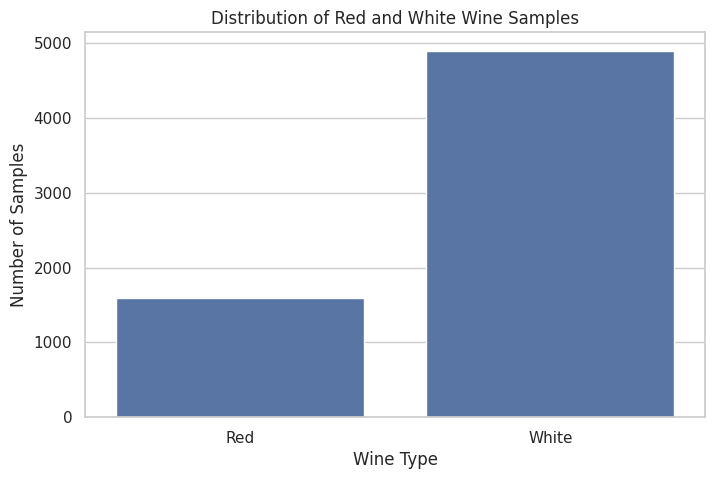

In [136]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="wine_type")

plt.title("Distribution of Red and White Wine Samples")
plt.xlabel("Wine Type")
plt.ylabel("Number of Samples")

plt.show()

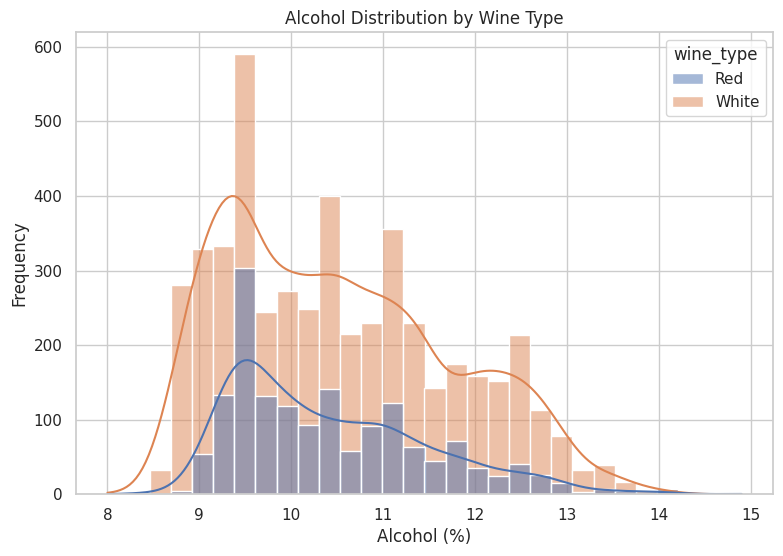

In [137]:
plt.figure(figsize=(9,6))

sns.histplot(
    data=df,
    x="alcohol",
    hue="wine_type",
    kde=True,
    bins=30
)

plt.title("Alcohol Distribution by Wine Type")
plt.xlabel("Alcohol (%)")
plt.ylabel("Frequency")

plt.show()

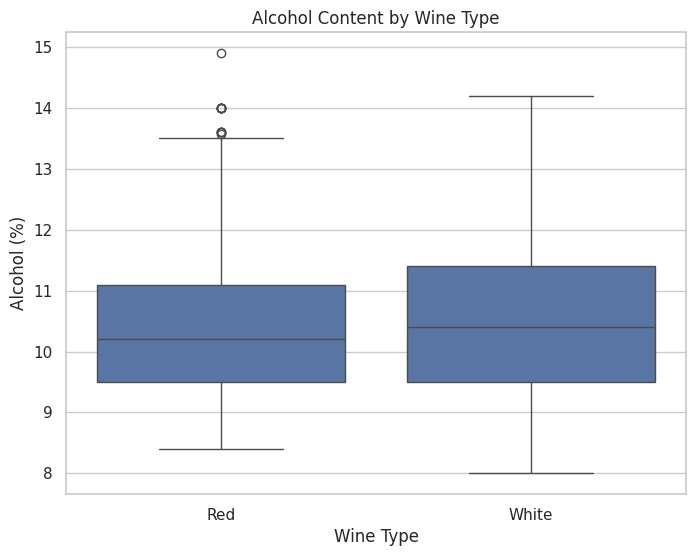

In [138]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="wine_type",
    y="alcohol"
)

plt.title("Alcohol Content by Wine Type")
plt.xlabel("Wine Type")
plt.ylabel("Alcohol (%)")

plt.show()

In [139]:
from math import sqrt

n1 = len(red_alcohol)
n2 = len(white_alcohol)

pooled_sd = sqrt(
    ((n1 - 1) * red_alcohol.var(ddof=1) +
     (n2 - 1) * white_alcohol.var(ddof=1))
    / (n1 + n2 - 2)
)

cohens_d = (
    red_alcohol.mean() - white_alcohol.mean()
) / pooled_sd

print("Cohen's d:", cohens_d)

Cohen's d: -0.07657051761217168


### Effect Size – Cohen's d

Cohen's d is used to describe the standardized magnitude of the difference in mean alcohol content between red and white wines.

The p-value determines whether the difference is statistically significant, while Cohen's d provides information about the practical magnitude of the difference.

In [140]:
red_alcohol = df[df["wine_type"] == "Red"]["alcohol"]

white_alcohol = df[df["wine_type"] == "White"]["alcohol"]

In [141]:
print("Red wine mean alcohol:", red_alcohol.mean())
print("White wine mean alcohol:", white_alcohol.mean())

Red wine mean alcohol: 10.422983114446529
White wine mean alcohol: 10.514267047774602


In [142]:
t_stat, p_value = ttest_ind(
    red_alcohol,
    white_alcohol,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -2.8590287839639132
P-value: 0.004277779864993421


In [143]:
from math import sqrt

n1 = len(red_alcohol)
n2 = len(white_alcohol)

pooled_sd = sqrt(
    ((n1 - 1) * red_alcohol.var(ddof=1) +
     (n2 - 1) * white_alcohol.var(ddof=1))
    / (n1 + n2 - 2)
)

cohens_d = (
    red_alcohol.mean() - white_alcohol.mean()
) / pooled_sd

print("Cohen's d:", cohens_d)

Cohen's d: -0.07657051761217168


## Tukey HSD Post-Hoc Analysis

Because the ANOVA test indicated a statistically significant difference in mean alcohol content across wine quality groups, a Tukey HSD post-hoc test was performed to identify which specific quality groups differed.

The Tukey HSD results show that several pairs of quality groups have statistically significant differences in mean alcohol content, while some pairs do not show significant differences.

For example, quality groups 3 and 7, 3 and 8, and 3 and 9 show statistically significant differences. Quality groups 7 and 9 and 8 and 9 do not show statistically significant differences after the Tukey adjustment.

The Tukey HSD procedure controls the family-wise error rate when making multiple pairwise comparisons.

Therefore, the ANOVA finding that at least one quality group differs is supported by specific pairwise comparisons, while also showing that not every quality group differs significantly from every other group.

## T-test Results and Interpretation

The mean alcohol content was approximately 10.423% for red wine and 10.514% for white wine.

The Welch independent samples t-test produced a t-statistic of approximately -2.859 and a p-value of approximately 0.0043.

Because the p-value is less than the significance level of 0.05, the null hypothesis is rejected.

Therefore, there is statistically significant evidence of a difference in mean alcohol content between red and white wines in this dataset.

The estimated mean difference (red minus white) is approximately -0.091 percentage points. The 95% confidence interval for the mean difference is approximately [-0.154, -0.029]. Because the confidence interval does not contain zero, it is consistent with the statistically significant result.

In [144]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is statistically significant evidence of a difference in mean alcohol content.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is insufficient evidence of a difference in mean alcohol content.")

Reject the null hypothesis.
There is statistically significant evidence of a difference in mean alcohol content.


## ANOVA Results and Interpretation

The one-way ANOVA produced an F-statistic of approximately 320.593 with a p-value below 0.001.

Because the p-value is less than 0.05, the null hypothesis is rejected.

Therefore, there is statistically significant evidence that mean alcohol content is not the same across all wine quality score groups.

However, ANOVA only tells us that at least one group differs. It does not identify exactly which quality groups differ from each other. A post-hoc analysis would be required to determine the specific group differences.

In [145]:
mean_difference = red_alcohol.mean() - white_alcohol.mean()

print("Mean difference:", mean_difference)

Mean difference: -0.09128393332807327


In [146]:
n1 = len(red_alcohol)
n2 = len(white_alcohol)

mean1 = red_alcohol.mean()
mean2 = white_alcohol.mean()

var1 = red_alcohol.var(ddof=1)
var2 = white_alcohol.var(ddof=1)

se = np.sqrt(var1/n1 + var2/n2)

df_welch = (var1/n1 + var2/n2)**2 / (
    (var1/n1)**2/(n1-1) +
    (var2/n2)**2/(n2-1)
)

critical_value = stats.t.ppf(0.975, df_welch)

ci_low = mean_difference - critical_value * se
ci_high = mean_difference + critical_value * se

print("95% Confidence Interval:")
print(ci_low, ci_high)

95% Confidence Interval:
-0.15388669330368496 -0.028681173352461592


In [147]:
df["quality"].value_counts().sort_index()

,count
quality,
3,30
4,216
5,2138
6,2836
7,1079
8,193
9,5


In [148]:
quality_groups = [
    group["alcohol"].values
    for _, group in df.groupby("quality")
]

In [149]:
f_stat, p_value_anova = f_oneway(*quality_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value_anova)

F-statistic: 320.5934478029266
P-value: 0.0


In [150]:
if p_value_anova < 0.05:
    print("Reject the null hypothesis.")
    print("Mean alcohol content differs significantly across at least some quality groups.")
else:
    print("Fail to reject the null hypothesis.")

Reject the null hypothesis.
Mean alcohol content differs significantly across at least some quality groups.


In [151]:
grand_mean = df["alcohol"].mean()

ss_between = sum(
    len(group) * (group["alcohol"].mean() - grand_mean) ** 2
    for _, group in df.groupby("quality")
)

ss_total = sum(
    (df["alcohol"] - grand_mean) ** 2
)

eta_squared = ss_between / ss_total

print("Eta-squared:", eta_squared)

Eta-squared: 0.22862623310382843


In [152]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(
    endog=df["alcohol"],
    groups=df["quality"],
    alpha=0.05
)

print(tukey_result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     3      4  -0.0349    1.0 -0.6371  0.5673  False
     3      5  -0.3772  0.442 -0.9455   0.191  False
     3      6   0.3726 0.4558 -0.1947  0.9398  False
     3      7    1.171    0.0  0.5989  1.7431   True
     3      8   1.4638    0.0  0.8572  2.0703   True
     3      9    1.965  0.002   0.472   3.458   True
     4      5  -0.3423 0.0001  -0.563 -0.1216   True
     4      6   0.4075    0.0  0.1893  0.6256   True
     4      7   1.2059    0.0  0.9755  1.4363   True
     4      8   1.4987    0.0  1.1925  1.8048   True
     4      9   1.9999 0.0005  0.6017  3.3981   True
     5      6   0.7498    0.0  0.6612  0.8383   True
     5      7   1.5482    0.0  1.4328  1.6636   True
     5      8    1.841    0.0  1.6087  2.0733   True
     5      9   2.3422    0.0  0.9583  3.7261   True
     6      7   0.7985    0.0  0.6879   0.909 

## Tukey HSD Post-Hoc Analysis

Because the ANOVA test showed a statistically significant difference in mean alcohol content across wine quality groups, Tukey's HSD post-hoc test was performed to identify which specific quality groups differed.

The results show that several quality-score pairs have statistically significant differences in mean alcohol content, while some pairs do not. The adjusted p-values account for multiple pairwise comparisons.

Therefore, the Tukey HSD analysis helps identify the specific quality groups contributing to the overall ANOVA result.

The results indicate differences between quality groups, but they should not be interpreted as evidence that alcohol content causes wine quality.

### Effect Size – Eta Squared

Eta squared is used to estimate the proportion of total variation in alcohol content associated with wine quality groups.

This complements the ANOVA p-value by providing information about the magnitude of the group effect.

## Chi-Square Results and Interpretation

The chi-square test produced a chi-square statistic of approximately 49.209 with 1 degree of freedom and a p-value of approximately 2.30 × 10⁻¹².

Because the p-value is far below 0.05, the null hypothesis is rejected.

Therefore, there is statistically significant evidence of an association between wine type and the defined quality group.

This result indicates that the distribution of High Quality and Standard Quality wines differs between red and white wine categories.

The test demonstrates association, not causation.

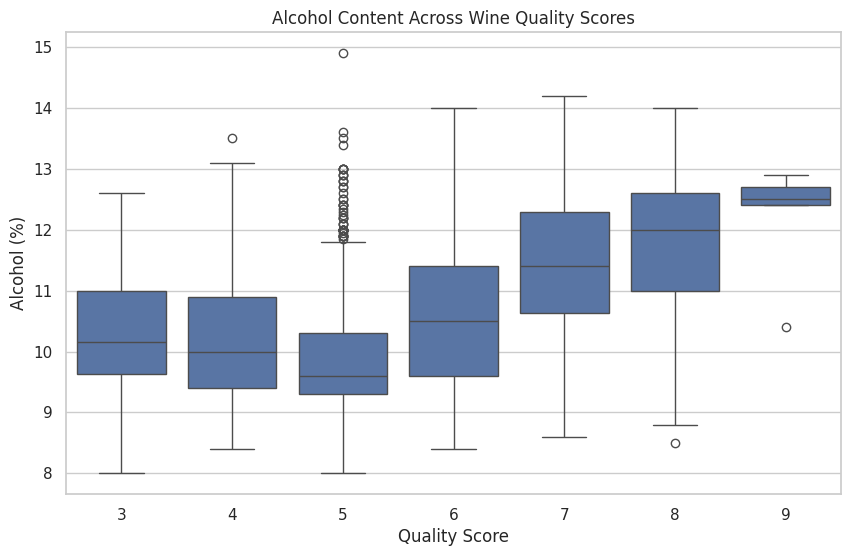

In [153]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="quality",
    y="alcohol"
)

plt.title("Alcohol Content Across Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Alcohol (%)")

plt.show()

In [154]:
df["quality_group"] = np.where(
    df["quality"] >= 7,
    "High Quality",
    "Standard Quality"
)

In [155]:
pd.crosstab(
    df["wine_type"],
    df["quality_group"]
)

quality_group,High Quality,Standard Quality
wine_type,,
Red,217,1382
White,1060,3838


In [156]:
contingency_table = pd.crosstab(
    df["wine_type"],
    df["quality_group"]
)

chi2, p_value_chi, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("P-value:", p_value_chi)
print("Degrees of freedom:", dof)

Chi-square statistic: 49.20899682339883
P-value: 2.300929727193776e-12
Degrees of freedom: 1


In [157]:
if p_value_chi < 0.05:
    print("Reject the null hypothesis.")
    print("Wine type and quality group are significantly associated.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is insufficient evidence of an association.")

Reject the null hypothesis.
Wine type and quality group are significantly associated.


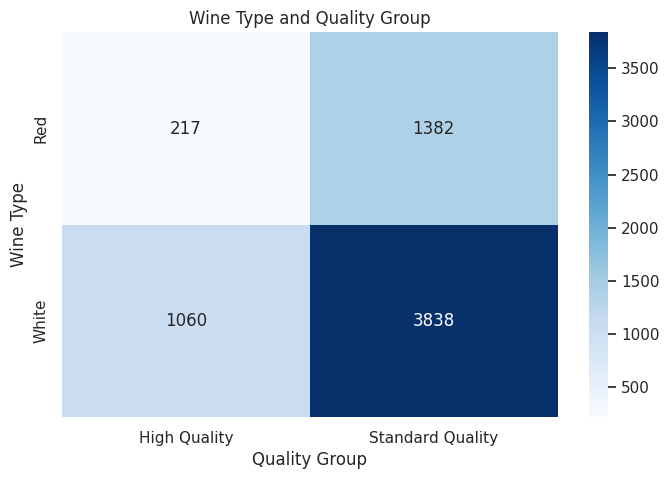

In [158]:
plt.figure(figsize=(8,5))

sns.heatmap(
    contingency_table,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Wine Type and Quality Group")
plt.xlabel("Quality Group")
plt.ylabel("Wine Type")

plt.show()

In [159]:
n = contingency_table.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 / (n * min(contingency_table.shape[0] - 1,
                    contingency_table.shape[1] - 1))
)

print("Cramer's V:", cramers_v)

Cramer's V: 0.0870293665338286


### Effect Size – Cramér's V

Cramér's V is used to describe the strength of association between wine type and quality group.

The chi-square p-value indicates whether the association is statistically significant, while Cramér's V provides information about the strength of that association.

## Statistical Test Summary

| Test | Question | p-value | Decision | Conclusion |
|---|---|---:|---|---|
| Welch t-test | Red vs White alcohol | 0.0043 | Reject H₀ | Significant difference in mean alcohol |
| One-way ANOVA | Alcohol across quality scores | < 0.001 | Reject H₀ | At least one quality group differs |
| Chi-square | Wine type vs quality group | 2.30 × 10⁻¹² | Reject H₀ | Significant association |

# Overall Conclusion

The statistical analysis provides evidence of significant relationships within the Wine Quality dataset.

The Welch independent samples t-test found a statistically significant difference in mean alcohol content between red and white wines. The one-way ANOVA also found statistically significant differences in mean alcohol content across wine quality score groups. Finally, the chi-square test found a statistically significant association between wine type and the defined quality group.

All three tests resulted in rejection of their respective null hypotheses at the 0.05 significance level.

These findings demonstrate how statistical hypothesis testing can be used to determine whether patterns observed in data are statistically significant rather than relying only on visual differences.

However, statistical significance does not establish causation. The results should therefore be interpreted as evidence of differences or associations within this dataset.